# Práctica 10 LDA

In [15]:
%pip install pypdf gensim pyldavis wordcloud 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\venss\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [55]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.datasets import fetch_20newsgroups
import Stopwords_Copy
import Reglas_Lematizador_Copy
import Preprocesamiento_Copy
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [56]:
import importlib

import Stopwords_Copy
import Reglas_Lematizador_Copy
import Preprocesamiento_Copy

importlib.reload(Stopwords_Copy)
importlib.reload(Reglas_Lematizador_Copy)
importlib.reload(Preprocesamiento_Copy)

<module 'Preprocesamiento_Copy' from 'C:\\Users\\venss\\Documents\\ESCOM\\6_Semestre\\PLN\\Procesamiento_lenguaje_natural\\Prácticas_U3\\Preprocesamiento_Copy.py'>

## Carga de 500 documentos

In [57]:
datos = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)

df = pd.DataFrame({
    "texto_original": datos.data,
    "categoria_id": datos.target,
    "categoria": [datos.target_names[i] for i in datos.target]
})

df.head()

,texto_original,categoria_id,categoria
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


## Funciones para limpiar corpus

In [58]:
df["num_palabras_original"] = df["texto_original"].apply(
    Preprocesamiento_Copy.contador_palabras)

In [59]:
df = df[df["num_palabras_original"] >= 50].copy()

df_500 = df.head(500).copy()

df_500.reset_index(drop=True, inplace=True)

df_500.insert(0, "id_documento", range(1, len(df_500) + 1))

## Aplicar limpieza del corpus

In [60]:
df_500["texto_minusculas"] = df_500["texto_original"].apply(
    Preprocesamiento_Copy.to_minusculas)

df_500["tokens"] = df_500["texto_minusculas"].apply(
    Preprocesamiento_Copy.tokenizador)

df_500["tokens_lematizados"] = df_500["tokens"].apply(
    Preprocesamiento_Copy.lematizador)

df_500["texto_limpio"] = df_500["tokens_lematizados"].apply(
    lambda tokens: " ".join(tokens))

df_500["num_tokens_limpios"] = df_500["tokens_lematizados"].apply(
    Preprocesamiento_Copy.contar_lista)

Eliminar documentos vacíos

In [61]:
df_500 = df_500[df_500["num_tokens_limpios"] > 0].copy()

df_500.reset_index(drop=True, inplace=True)

df_500["id_documento"] = range(1, len(df_500) + 1)

Corpus limpio

In [62]:
df_500.to_csv(
    "corpus_500_documentos_limpio.csv",
    index=False,
    encoding="utf-8-sig")

print(df_500[["id_documento", "categoria", "num_palabras_original",
              "num_tokens_limpios", "texto_limpio"]].head())

   id_documento                 categoria  num_palabras_original  \
0             1          rec.sport.hockey                    137   
1             2  comp.sys.ibm.pc.hardware                     53   
2             3     talk.politics.mideast                    241   
3             4  comp.sys.ibm.pc.hardware                    144   
4             5     comp.sys.mac.hardware                    125   

   num_tokens_limpios                                       texto_limpio  
0                  58  basher pen fan pretty confus lack kin recent p...  
1                  30  brother market high performance video car supp...  
2                  92  final dream mediterranean area greater holocau...  
3                  59  scsi car dma transfer disk scsi car dma transf...  
4                  38  jasmine drive cannot system understand upsate ...  


## Modelado de Tópicos con LDA
Parámetros 

In [63]:
N_TOPICS = 5    # numero de temas a identificar
M_WORDS  = 50   # palabras por nube de palabras

Preparar diccionario y corpus para Gensim

In [64]:
tokenized_docs = df_500["tokens_lematizados"].tolist()

diccionario = corpora.Dictionary(tokenized_docs)

diccionario.filter_extremes(no_below=2, no_above=0.9) #elimina palabras que aparecen en menos de 2 documentos  o en más del 90% de documentos 

corpus_bow = [diccionario.doc2bow(doc) for doc in tokenized_docs]

print(f"Vocabulario: {len(diccionario)} términos únicos")
print(f"Documentos:  {len(corpus_bow)}")

Vocabulario: 4321 términos únicos
Documentos:  500


Entrenar modelo LDA

In [65]:
lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=diccionario,
    num_topics=N_TOPICS,
    random_state=42,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

print("Tópicos encontrados:\n") #que tan probable es que cada palabra pertenezca a cada tópico
for idx, topico in lda_model.print_topics(num_words=10):
    print(f"  Tópico {idx+1}: {topico}\n")

Tópicos encontrados:

  Tópico 1: 0.007*"system" + 0.006*"key" + 0.006*"datum" + 0.006*"chip" + 0.006*"car" + 0.005*"bit" + 0.005*"work" + 0.004*"com" + 0.004*"image" + 0.004*"disk"

  Tópico 2: 0.006*"work" + 0.005*"key" + 0.005*"car" + 0.005*"group" + 0.004*"two" + 0.004*"government" + 0.004*"etc" + 0.003*"bit" + 0.003*"thank" + 0.003*"both"

  Tópico 3: 0.008*"window" + 0.007*"edu" + 0.007*"program" + 0.006*"server" + 0.006*"det" + 0.006*"nyr" + 0.006*"client" + 0.005*"work" + 0.004*"file" + 0.004*"start"

  Tópico 4: 0.010*"president" + 0.006*"stat" + 0.005*"work" + 0.005*"unit" + 0.004*"space" + 0.004*"believe" + 0.004*"order" + 0.004*"two" + 0.004*"such" + 0.004*"option"

  Tópico 5: 0.011*"armenian" + 0.009*"law" + 0.006*"christian" + 0.006*"history" + 0.005*"jesu" + 0.005*"such" + 0.005*"text" + 0.004*"muslim" + 0.004*"university" + 0.004*"believe"



Distribución de tópicos por documento

In [66]:
topico_dominante = [] #tomar el topico mas domimante para cada documento
for bow in corpus_bow:
    distribucion = lda_model.get_document_topics(bow)
    if distribucion:
        topico_dom = max(distribucion, key=lambda x: x[1])[0]
    else:
        topico_dom = -1
    topico_dominante.append(topico_dom + 1)  

df_500["topico_dominante"] = topico_dominante

print(df_500[["id_documento", "categoria", "topico_dominante"]].head(10))

   id_documento                 categoria  topico_dominante
0             1          rec.sport.hockey                 2
1             2  comp.sys.ibm.pc.hardware                 2
2             3     talk.politics.mideast                 5
3             4  comp.sys.ibm.pc.hardware                 1
4             5     comp.sys.mac.hardware                 1
5             6           sci.electronics                 3
6             7          rec.sport.hockey                 3
7             8          rec.sport.hockey                 5
8             9        talk.religion.misc                 5
9            10        talk.religion.misc                 4


Palabras de cada topico

In [67]:

print(f"{'Tópico':<10} {'Palabras más representativas'}")
for i in range(N_TOPICS):
    palabras = [palabra for palabra, peso in lda_model.show_topic(i, topn=20)]
    print(f"Tópico {i+1:<5} {', '.join(palabras)}")

Tópico     Palabras más representativas
Tópico 1     system, key, datum, chip, car, bit, work, com, image, disk, drive, software, driver, program, color, video, please, thank, water, call
Tópico 2     work, key, car, group, two, government, etc, bit, thank, both, right, interest, current, please, public, such, seem, man, support, too
Tópico 3     window, edu, program, server, det, nyr, client, work, file, start, resourc, better, application, xterm, set, doesn, font, system, fil, com
Tópico 4     president, stat, work, unit, space, believe, order, two, such, option, right, war, church, idea, action, position, station, without, law, country
Tópico 5     armenian, law, christian, history, jesu, such, text, muslim, university, believe, turkey, day, evidence, commandment, sabbath, belief, claim, statement, man, population


Nube de palabras por tópico

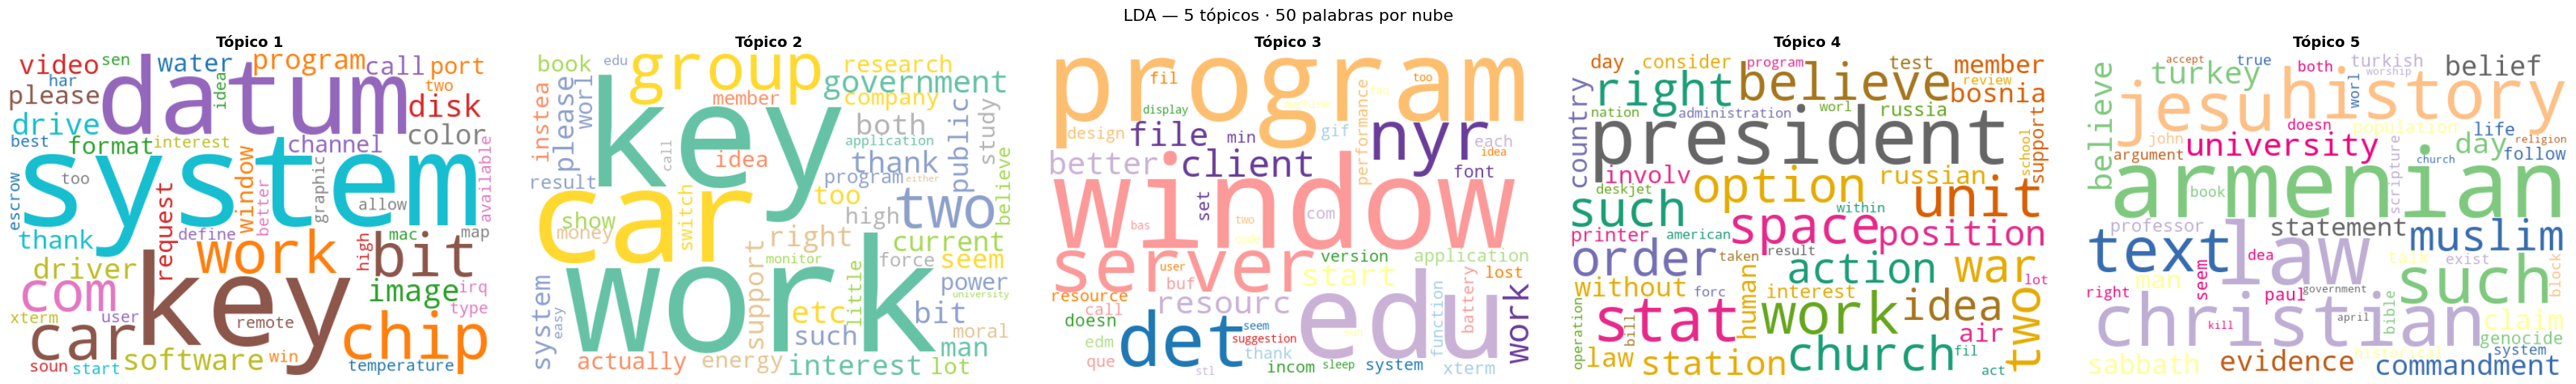

In [68]:
fig, axes = plt.subplots(1, N_TOPICS, figsize=(7 * N_TOPICS, 5))

if N_TOPICS == 1:
    axes = [axes]

colormaps = ["tab10", "Set2", "Paired", "Dark2", "Accent"]

for i, ax in enumerate(axes):
    #M palabras más probables de un tópico con su peso
    palabras_pesos = dict(lda_model.show_topic(i, topn=M_WORDS))

    nube = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=colormaps[i % len(colormaps)],
        max_words=M_WORDS
    ).generate_from_frequencies(palabras_pesos)

    ax.imshow(nube, interpolation="bilinear")
    ax.set_title(f"Tópico {i+1}", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.suptitle(
    f"LDA — {N_TOPICS} tópicos · {M_WORDS} palabras por nube",
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()